# Week 5: AI-Assisted Triage: Data Exploration (Part 1 of 2)

This notebook uses the **Yale EMMLC triage extract** dataset (a de-identified arrivals dataset).

## 1. Setup

In [2]:
# Run this cell first.
import numpy as np # numerical helpers
import pandas as pd # tables / DataFrames
import matplotlib.pyplot as plt # plotting
from pathlib import Path

# Let pandas show more of a wide table when printing
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

# All figures produced in this notebook are saved here.
Path("figs").mkdir(exist_ok=True)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 3.0.3


## 2. Load data

In [4]:
DATA_PATH = Path("yaleemmlc_admissionprediction_triage.csv")

df = pd.read_csv(DATA_PATH, index_col=0)   # index_col=0 drops the unnamed export index
print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,...,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Shape and structural overview

**ANALYTICAL NOTE:** Chief-complaint flags (`cc_*`) are complete-by-design: 0/1 indicators, not free-standing measurements. So,we separate them from the **structured** clinical/demographic columns before profiling missingness and types. Otherwise, ~200 always-populated flag columns would drown out the columns that actually have gaps.

In [5]:

structured = [c for c in df.columns if not c.startswith("cc_")]
cc_flags   = [c for c in df.columns if c.startswith("cc_")]

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Structured columns ({len(structured)}):")
for c in structured:
    print("   ", c)
print(f"\nChief-complaint flags (cc_*): {len(cc_flags)}")

Shape: 55,121 rows x 225 columns
Structured columns (25):
    dep_name
    esi
    age
    gender
    ethnicity
    race
    lang
    religion
    maritalstatus
    employstatus
    insurance_status
    disposition
    arrivalmode
    arrivalmonth
    arrivalday
    arrivalhour_bin
    previousdispo
    triage_vital_hr
    triage_vital_sbp
    triage_vital_dbp
    triage_vital_rr
    triage_vital_o2
    triage_vital_o2_device
    triage_vital_temp
    triage_glucose

Chief-complaint flags (cc_*): 200


**CLINICAL CONTEXT:** This is a **wide, sparse** dataset: most columns describe a single encounter thinly (one chief-complaint flag fires per patient), while a small core of demographic and vital-sign columns carries most of the analytical weight. Structural summaries below focus on that structured core.

## 4. `.info()` - Structural snapshot

In [6]:
print("Column types at a glance:")
print(df.dtypes.value_counts(), "\n")     # how many numeric vs text columns

print("A compact structural summary of just the structured columns:")
df[structured].info()

Column types at a glance:
float64    210
str         15
Name: count, dtype: int64 

A compact structural summary of just the structured columns:
<class 'pandas.DataFrame'>
Index: 55121 entries, 7 to 433332
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dep_name                55121 non-null  str    
 1   esi                     55121 non-null  float64
 2   age                     55121 non-null  float64
 3   gender                  55121 non-null  str    
 4   ethnicity               55121 non-null  str    
 5   race                    55121 non-null  str    
 6   lang                    55121 non-null  str    
 7   religion                55121 non-null  str    
 8   maritalstatus           55121 non-null  str    
 9   employstatus            55121 non-null  str    
 10  insurance_status        55121 non-null  str    
 11  disposition             55121 non-null  str    
 12  arrivalmode   

**ANALYTICAL NOTE:** `.info()` gives, per column: its dtype and its count of **non-null** values. So, any column whose non-null count is below the total row count already flags itself as incomplete here.

## 5. `.describe()` - Numeric and categorical summaries

In [7]:
numeric_cols = df[structured].select_dtypes(include="number").columns.tolist()
print("Numeric columns:")
df[numeric_cols].describe().round(2)

Numeric columns:


,esi,age,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose
count,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00
mean,2.88,55.32,86.45,133.68,79.53,17.84,97.02,0.07,98.09,130.09
std,0.75,19.54,16.96,22.65,14.59,2.07,2.08,0.25,0.81,73.66
min,1.00,18.00,32.00,53.00,27.00,8.00,62.00,0.00,91.50,16.00
25%,2.00,40.00,74.00,118.00,70.00,16.00,96.00,0.00,97.70,93.00
50%,3.00,55.00,85.00,132.00,79.00,18.00,98.00,0.00,98.00,107.00
75%,3.00,70.00,97.00,147.00,89.00,18.00,98.00,0.00,98.40,134.00
max,5.00,107.00,221.00,266.00,189.00,66.00,99.00,1.00,106.00,1066.00


In [8]:
cat_cols = [c for c in structured if c not in numeric_cols]
print("Categorical / text columns:")
df[cat_cols].describe()

Categorical / text columns:


,dep_name,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo
count,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121,55121
unique,3,2,4,8,2,12,10,10,5,2,7,12,7,6,10
top,A,Female,Non-Hispanic,White or Caucasian,English,Catholic,Single,Retired,Medicaid,Discharge,Car,June,Monday,11-14,Discharge
freq,34933,31744,45142,29435,50264,23550,22901,17058,21427,34565,22797,5987,8687,15872,28627


**ANALYTICAL NOTE:** For categorical columns, `.describe()` reports `count` (non-null rows), `unique` (distinct categories), and the most frequent category with its frequency (`top` / `freq`), the categorical equivalent of mean/median for a number column.

## 6. Data type audit + target sanity

In [10]:
print(df[structured].dtypes)
print("\nESI value counts (raw):"); print(df["esi"].value_counts(dropna=False).sort_index())

dep_name                      str
esi                       float64
age                       float64
gender                        str
ethnicity                     str
race                          str
lang                          str
religion                      str
maritalstatus                 str
employstatus                  str
insurance_status              str
disposition                   str
arrivalmode                   str
arrivalmonth                  str
arrivalday                    str
arrivalhour_bin               str
previousdispo                 str
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
dtype: object

ESI value counts (raw):
esi
1.0       77
2.0    17924
3.0    27010
4.0     8896
5.0     1214
Name: count, dtype: int64


**ANALYTICAL NOTE:** All columns are of the correct types. Therefore, no corrections are needed.

## 7. Missing values

**ANALYTICAL NOTE:** A raw count of missing cells is hard to interpret on its own. Reporting **both** the count and the percentage keeps the audit honest and comparable across datasets.

In [11]:
missing_count = df[structured].isna().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct":   missing_pct,
    "dtype":         df[structured].dtypes.astype(str),
})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_pct", ascending=False)

print(f"{len(missing_report)} of {len(structured)} structured columns have at least one missing value.\n")
missing_report

0 of 25 structured columns have at least one missing value.



,missing_count,missing_pct,dtype


## 8. Missingness visualisation

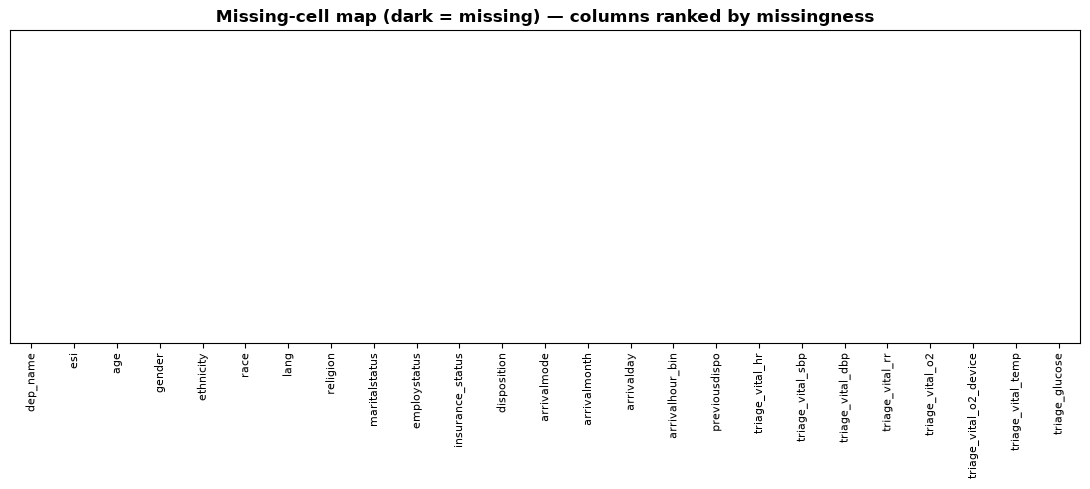

In [12]:
# Missing-cell map, columns ordered worst-missing first
ordered_cols = missing_report.index.tolist() + [c for c in structured if c not in missing_report.index]

try:
    import missingno as msno
    msno.matrix(df[ordered_cols])
    plt.title("Missing-cell map (columns ranked by missingness)")
    plt.tight_layout()
    plt.savefig("figs/missingness_matrix.png", dpi=150)
    plt.show()
except ImportError:
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.imshow(df[ordered_cols].isna().values, aspect="auto", cmap="gray_r", interpolation="nearest")
    ax.set_xticks(range(len(ordered_cols)))
    ax.set_xticklabels(ordered_cols, rotation=90, fontsize=8)
    ax.set_yticks([])
    ax.set_title("Missing-cell map (dark = missing) — columns ranked by missingness", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figs/missingness_matrix.png", dpi=150)
    plt.show()

**ANALYTICAL NOTE:** No columns with missing values. Therefore, no imputation is needed.

## 9. Outlier Detection

**CLINICAL CONTEXT:** a vital sign can be *unusual* (statistically rare but physiologically real -- e.g. a very fit patient's resting pulse of 45 bpm) or *impossible* (a data-entry error -- e.g. a pulse of 3 bpm). We use two complementary, well-established methods plus a clinical sanity check:
- **1.5×IQR fence** -- a distribution-based, unit-agnostic flag for statistically rare values.
- **|z-score| > 3** -- flags values more than 3 standard deviations from the column mean.
- **Physiologically implausible bounds** -- hard limits a live human could not fall outside of (e.g. heart rate below 20 bpm or above 250 bpm), regardless of what the rest of the distribution looks like.

Values outside the plausible bounds should be treated as data errors, not as evidence of an extremely sick patient, and are candidates for correction or removal rather than modelling.

In [13]:
# Reference ("normal") ranges for adult ED triage vitals -- used for axis labels and shading below,
# not for flagging outliers. NOTE: temperature is recorded in FAHRENHEIT in this dataset.
NORMAL_RANGES = {
    "triage_vital_hr":   (60, 100, "bpm"),
    "triage_vital_sbp":  (90, 140, "mmHg"),
    "triage_vital_dbp":  (60, 90,  "mmHg"),
    "triage_vital_rr":   (12, 20,  "/min"),
    "triage_vital_o2":   (95, 100, "%"),
    "triage_vital_temp": (97.0, 99.5, "F"),
    "triage_glucose":    (70, 140, "mg/dL"),
}

# "Plausible" bounds are deliberately much wider than normal -- anything OUTSIDE these is a
# physiologically implausible value (almost certainly a data-entry error), not a very sick patient.
PLAUSIBLE = {
    "triage_vital_hr":   (20, 250),
    "triage_vital_sbp":  (50, 300),
    "triage_vital_dbp":  (20, 200),
    "triage_vital_rr":   (4, 60),
    "triage_vital_o2":   (50, 100),
    "triage_vital_temp": (86, 110),
    "triage_glucose":    (20, 800),
}

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

def outlier_report(series, plausible_bounds):
    """Count IQR outliers, |z|>3 outliers, and physiologically-implausible values in one numeric column."""
    x = pd.to_numeric(series, errors="coerce").dropna()

    # Method 1: 1.5 x IQR fence (distribution-based, robust to skew)
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    low_fence, high_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_outliers = int(((x < low_fence) | (x > high_fence)).sum())

    # Method 2: |z-score| > 3 (assumes a roughly-normal shape; sensitive to the mean/SD it is measured against)
    z = (x - x.mean()) / x.std()
    z_outliers = int((z.abs() > 3).sum())

    # Method 3: physiologically implausible (clinically impossible, regardless of distribution shape)
    low, high = plausible_bounds
    implausible = int(((x < low) | (x > high)).sum())

    n = len(x)
    return pd.Series({
        "n_values": n,
        "iqr_outliers": iqr_outliers,
        "iqr_outlier_pct": round(iqr_outliers / n * 100, 2),
        "zscore_outliers_|z|>3": z_outliers,
        "implausible_values": implausible,
        "implausible_pct": round(implausible / n * 100, 2),
    })

outlier_summary = pd.DataFrame({col: outlier_report(df[col], PLAUSIBLE[col]) for col in VITALS}).T
outlier_summary

,n_values,iqr_outliers,iqr_outlier_pct,zscore_outliers_|z|>3,implausible_values,implausible_pct
triage_vital_hr,55121.0,578.0,1.05,326.0,0.0,0.00
triage_vital_sbp,55121.0,1028.0,1.86,434.0,0.0,0.00
triage_vital_dbp,55121.0,726.0,1.32,325.0,0.0,0.00
triage_vital_rr,55121.0,2366.0,4.29,514.0,4.0,0.01
triage_vital_o2,55121.0,1505.0,2.73,706.0,0.0,0.00
triage_vital_temp,55121.0,3554.0,6.45,858.0,0.0,0.00
triage_glucose,55121.0,5673.0,10.29,1363.0,25.0,0.05


**ANALYTICAL NOTE:** the table above answers *how many* implausible values exist per vital; the chart below answers *which vitals are the biggest data-quality risk*, so cleaning effort can be targeted rather than applied uniformly.

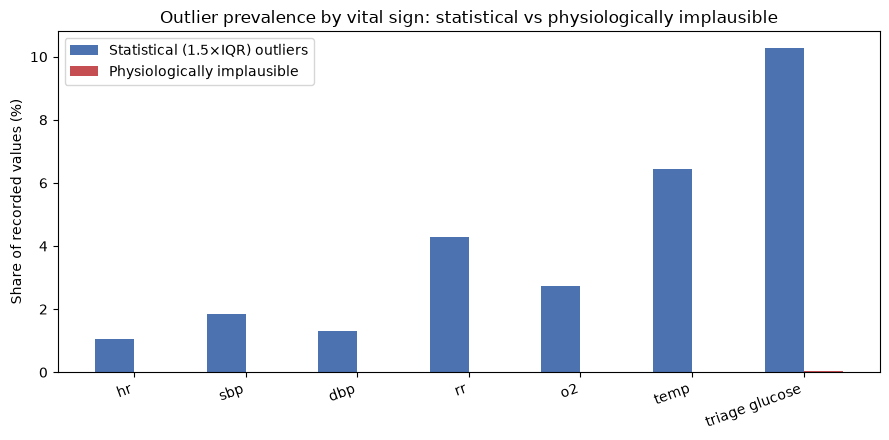

In [14]:
# Data-quality question: which vitals carry the most statistically-rare vs physiologically-impossible values?
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(VITALS))
width = 0.35

ax.bar(x - width/2, outlier_summary["iqr_outlier_pct"], width, label="Statistical (1.5×IQR) outliers", color="#4C72B0")
ax.bar(x + width/2, outlier_summary["implausible_pct"], width, label="Physiologically implausible", color="#C44E52")

ax.set_xticks(x)
ax.set_xticklabels([c.replace("triage_vital_", "").replace("_", " ") for c in VITALS], rotation=20, ha="right")
ax.set_ylabel("Share of recorded values (%)")
ax.set_title("Outlier prevalence by vital sign: statistical vs physiologically implausible")
ax.legend()
plt.tight_layout()
plt.savefig("figs/outlier_prevalence_by_vital.png", dpi=150)
plt.show()

## 10. Distribution analysis of key features

**CLINICAL CONTEXT:** before comparing vitals across triage groups, we look at each one's overall shape on its own: is it roughly symmetric (mean and median close together), skewed (e.g. glucose, which typically has a long right tail from hyperglycaemic patients), or multi-modal? This shapes which summary statistic to trust (mean vs median) and whether a transformation would be needed before modelling. The shaded band on each panel marks the textbook-normal range for that vital, purely as a visual reference. It is not a cleaning threshold.

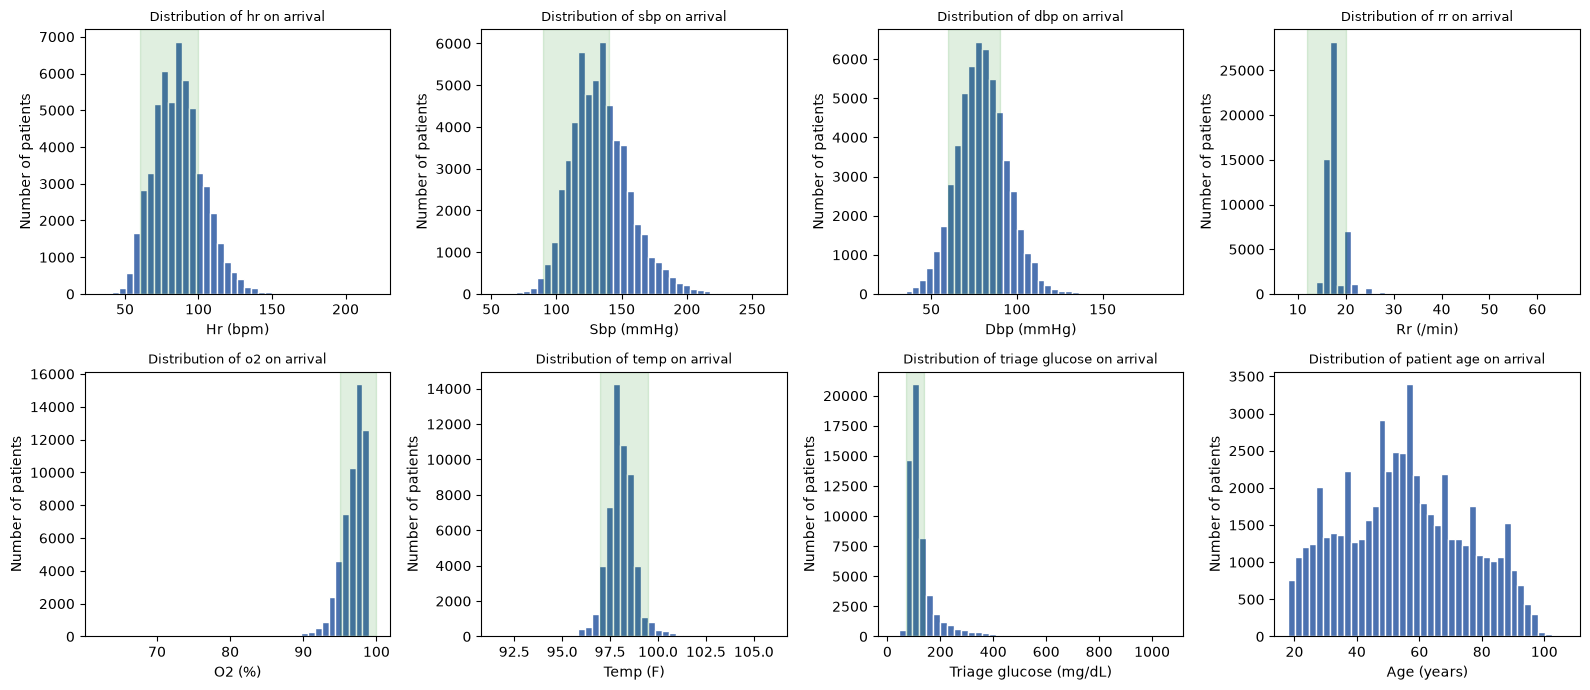

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
panels = axes.ravel()

for panel, col in zip(panels, VITALS):
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    low, high, unit = NORMAL_RANGES[col]
    label = col.replace("triage_vital_", "").replace("_", " ")
    panel.hist(values, bins=40, color="#4C72B0", edgecolor="white")
    panel.axvspan(low, high, color="green", alpha=0.12, label="normal range")
    panel.set_title(f"Distribution of {label} on arrival", fontsize=9)
    panel.set_xlabel(f"{label.capitalize()} ({unit})")
    panel.set_ylabel("Number of patients")

# Age fills the 8th panel of the 2x4 grid (7 vitals + age).
age = pd.to_numeric(df["age"], errors="coerce").dropna()
panels[-1].hist(age, bins=40, color="#4C72B0", edgecolor="white")
panels[-1].set_title("Distribution of patient age on arrival", fontsize=9)
panels[-1].set_xlabel("Age (years)")
panels[-1].set_ylabel("Number of patients")

plt.tight_layout()
plt.savefig("figs/distributions_vitals_age.png", dpi=150)
plt.show()

## 11. Triage_Level (ESI) distribution

**CLINICAL CONTEXT:** `Triage_Level` (ESI) is the acuity label assigned at the front door: 1 = most urgent (resuscitation) through 5 = least urgent (non-urgent). Its class balance matters for any downstream model: if one level dominates the sample, a classifier can score well overall by defaulting to the majority class while still missing the rare, most-urgent patients that matter most clinically.

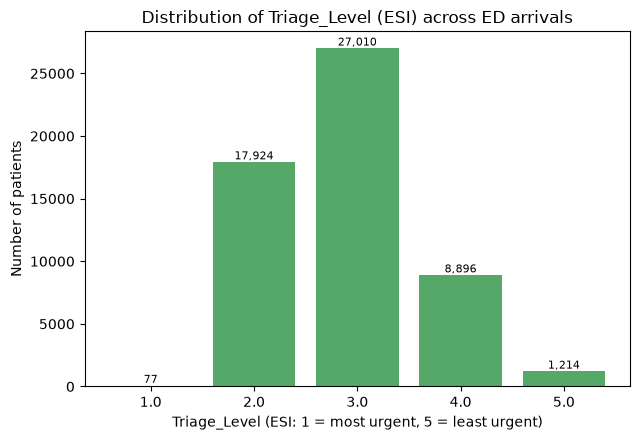

Share of arrivals by Triage_Level (%):
esi
1.0     0.1
2.0    32.5
3.0    49.0
4.0    16.1
5.0     2.2
Name: count, dtype: float64


In [17]:
triage_counts = df["esi"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(triage_counts.index.astype(str), triage_counts.values, color="#55A868")
ax.set_title("Distribution of Triage_Level (ESI) across ED arrivals")
ax.set_xlabel("Triage_Level (ESI: 1 = most urgent, 5 = least urgent)")
ax.set_ylabel("Number of patients")
for bar, v in zip(bars, triage_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("figs/triage_level_distribution.png", dpi=150)
plt.show()

print("Share of arrivals by Triage_Level (%):")
print((triage_counts / triage_counts.sum() * 100).round(1))

## 12. Vital signs by Triage_Level

**CLINICAL CONTEXT:** if triage is behaving as a physiological signal (and not purely a clerical judgement), the sicker patients (low `Triage_Level`) should show more deranged vitals. Comparing each vital's spread *across* Triage_Level groups is a direct check of that assumption, and shows which single vital is the strongest acuity signal on its own, useful context before any multivariate model is built.

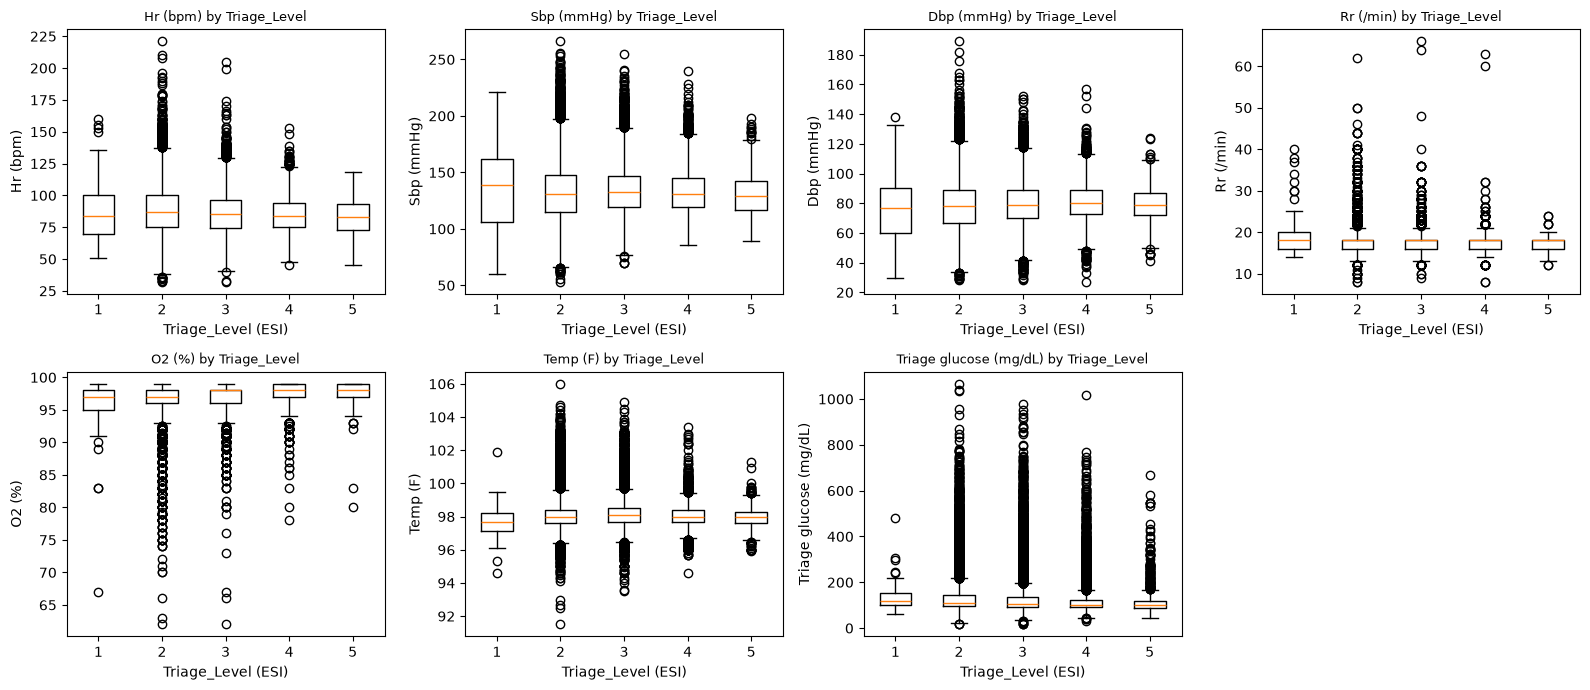

In [18]:
triage_levels = sorted(df["esi"].dropna().unique().tolist())

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
panels = axes.ravel()

for panel, col in zip(panels, VITALS):
    groups = [pd.to_numeric(df.loc[df["esi"] == level, col], errors="coerce").dropna()
              for level in triage_levels]
    low, high, unit = NORMAL_RANGES[col]
    label = col.replace("triage_vital_", "").replace("_", " ")
    panel.boxplot(groups, tick_labels=[str(int(l)) for l in triage_levels])
    panel.set_title(f"{label.capitalize()} ({unit}) by Triage_Level", fontsize=9)
    panel.set_xlabel("Triage_Level (ESI)")
    panel.set_ylabel(f"{label.capitalize()} ({unit})")

panels[-1].axis("off")  # 7 vitals in an 8-panel grid; the spare panel is left blank
plt.tight_layout()
plt.savefig("figs/vitals_by_triage_level.png", dpi=150)
plt.show()

## 13. Correlation analysis with Triage_Level

**ANALYTICAL NOTE:** correlation here is a directional sanity check, not a causal claim and not a model. `Triage_Level` runs 1 (most urgent) to 5 (least urgent), so a **negative** correlation between a vital and `Triage_Level` means that vital tends to be *higher* when urgency is *higher* (lower Triage_Level) -- the sign takes a moment to get used to.

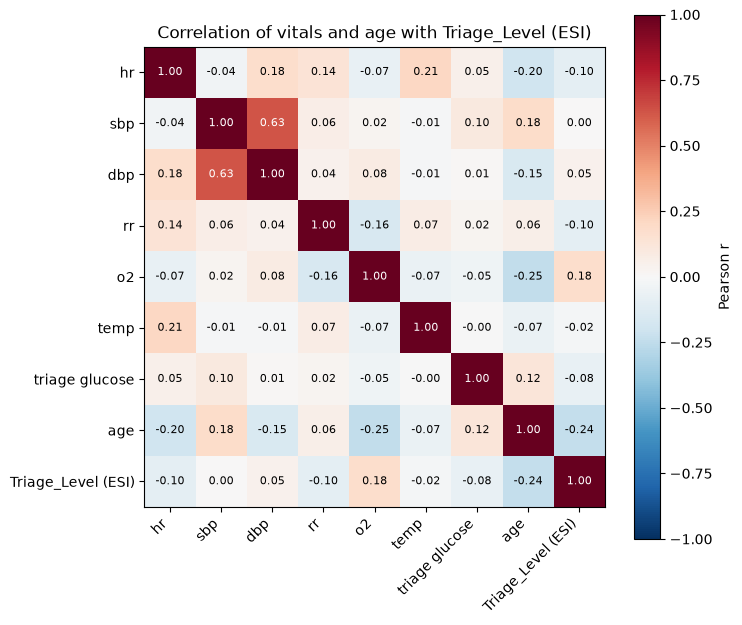

Vitals ranked by strength of correlation with Triage_Level:
age                 -0.237
triage_vital_o2      0.178
triage_vital_rr     -0.095
triage_vital_hr     -0.095
triage_glucose      -0.078
triage_vital_dbp     0.046
triage_vital_temp   -0.022
triage_vital_sbp     0.001
Name: esi, dtype: float64


In [21]:
corr_cols = VITALS + ["age", "esi"]
corr = df[corr_cols].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

labels = [c.replace("triage_vital_", "").replace("_", " ") for c in corr_cols[:-1]] + ["Triage_Level (ESI)"]
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(labels)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > 0.5 else "black")

ax.set_title("Correlation of vitals and age with Triage_Level (ESI)")
fig.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.savefig("figs/correlation_heatmap.png", dpi=150)
plt.show()

print("Vitals ranked by strength of correlation with Triage_Level:")
print(corr["esi"].drop("esi").reindex(corr["esi"].drop("esi").abs().sort_values(ascending=False).index).round(3))

**CLINICAL CONTEXT:** the vital(s) with the largest absolute correlation to `Triage_Level` are the strongest *single-variable* acuity signals in this dataset; the rest most likely add value mainly in combination with each other (e.g. inside a multivariate model) rather than alone, and near-zero correlations should not be read as "clinically irrelevant", only as "not linearly related to acuity on their own".

## 14. Data-quality summary

In [23]:
issues = []
for col, row in missing_report.iterrows():
    severity = "high" if row["missing_pct"] >= 25 else ("moderate" if row["missing_pct"] >= 10 else "low")
    issues.append({
        "column": col,
        "missing_pct": row["missing_pct"],
        "severity": severity,
        "suggested_action": "review for drop / imputation strategy" if severity != "low" else "monitor",
    })

# Fold the outlier / implausible-value findings from Section 9 into the same table.
for col, row in outlier_summary.iterrows():
    if row["implausible_pct"] > 0:
        issues.append({
            "column": col,
            "missing_pct": np.nan,
            "severity": "high" if row["implausible_pct"] >= 1 else "moderate",
            "suggested_action": f"{row['implausible_pct']}% physiologically implausible -- recode as missing, do not impute as-is",
        })
    elif row["iqr_outlier_pct"] >= 5:
        issues.append({
            "column": col,
            "missing_pct": np.nan,
            "severity": "moderate",
            "suggested_action": f"{row['iqr_outlier_pct']}% statistical outliers -- review, likely genuine extreme values",
        })

quality_summary = pd.DataFrame(issues)
quality_summary

,column,missing_pct,severity,suggested_action
0,triage_vital_rr,NaN,moderate,0.01% physiologically implausible -- recode as...
1,triage_vital_temp,NaN,moderate,"6.45% statistical outliers -- review, likely g..."
2,triage_glucose,NaN,moderate,0.05% physiologically implausible -- recode as...


## 15. Export Cleaned Dataset

In [24]:
# ── Schema map ────────────────────────────────────────────────────────────────
# This dataset has ~225 columns, so we never list them by hand. We sort them into
# "families" once, then refer to the families by name for the rest of the week.

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least). Our triage label.

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Helper: from a wish-list of names, keep only the ones that really exist in df.
    # (A plain function instead of a lambda, so it is easy to read.)
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # The ~200 chief-complaint columns all start with "cc_", so we find them by prefix:
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

In [25]:
import os
def clean_triage(raw):
    d = raw.copy()
    fam = classify_columns(d)

    # 1. Drop rows with no triage label — we cannot learn a decision the data never recorded.
    d = d[d[TARGET].notna()].copy()

    # 2. Make the vital-sign columns (and age) numeric. Any stray text becomes NaN.
    numeric_cols = list(fam["vitals"])          # a copy of the vital-column list
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # 3. Flag physiologically impossible values as missing (NaN) — do not "cap" them.
    for col in PLAUSIBLE:
        low, high = PLAUSIBLE[col]
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    # 4. Fill the gaps. Vitals -> median (a robust middle value).
    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())
    # A blank oxygen-device flag or chief-complaint flag means "not recorded" = 0.
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)
    # Text categories: a blank becomes the explicit category "Unknown".
    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    # 5. The target should be a whole number 1-5, not a decimal.
    d[TARGET] = d[TARGET].round().astype(int)
    return d

In [27]:
from pathlib import Path
CLEAN_PATH, RAW_PATH = Path("triage_cleaned_v1.csv"), Path("yaleemmlc_admissionprediction_triage.csv")
if CLEAN_PATH.exists():
    df = pd.read_csv(CLEAN_PATH); print("Loaded cleaned data from Tutorial 3")
elif RAW_PATH.exists():
    df = clean_triage(pd.read_csv(RAW_PATH, index_col=0))
    df.to_csv(CLEAN_PATH, index=False)
    print(f"Saved cleaned data to {CLEAN_PATH}")
else:
    raise FileNotFoundError("Need triage_cleaned_v1.csv or the raw CSV.")
raw = pd.read_csv(RAW_PATH, index_col=0) if RAW_PATH.exists() else None
fam = classify_columns(df); os.makedirs("figs", exist_ok=True); print(df.shape)

Saved cleaned data to triage_cleaned_v1.csv
(55121, 225)


## 15. Wrap-up

This notebook has measured: shape and dtypes, descriptive statistics, per-column missingness (counts and percentages), a dtype-inconsistency audit with corrections applied, outlier detection (1.5×IQR, |z|>3, and physiologically implausible bounds), distribution analysis of the key vitals and age, the `Triage_Level` (ESI) class balance, vital-sign spread across Triage_Level groups, and a correlation analysis of vitals and age against `Triage_Level`. Five figures were exported to `figs/`: the missingness map, the outlier-prevalence chart, the vitals/age distributions, the `Triage_Level` distribution, the vitals-by-`Triage_Level` box plots, and the correlation heatmap.